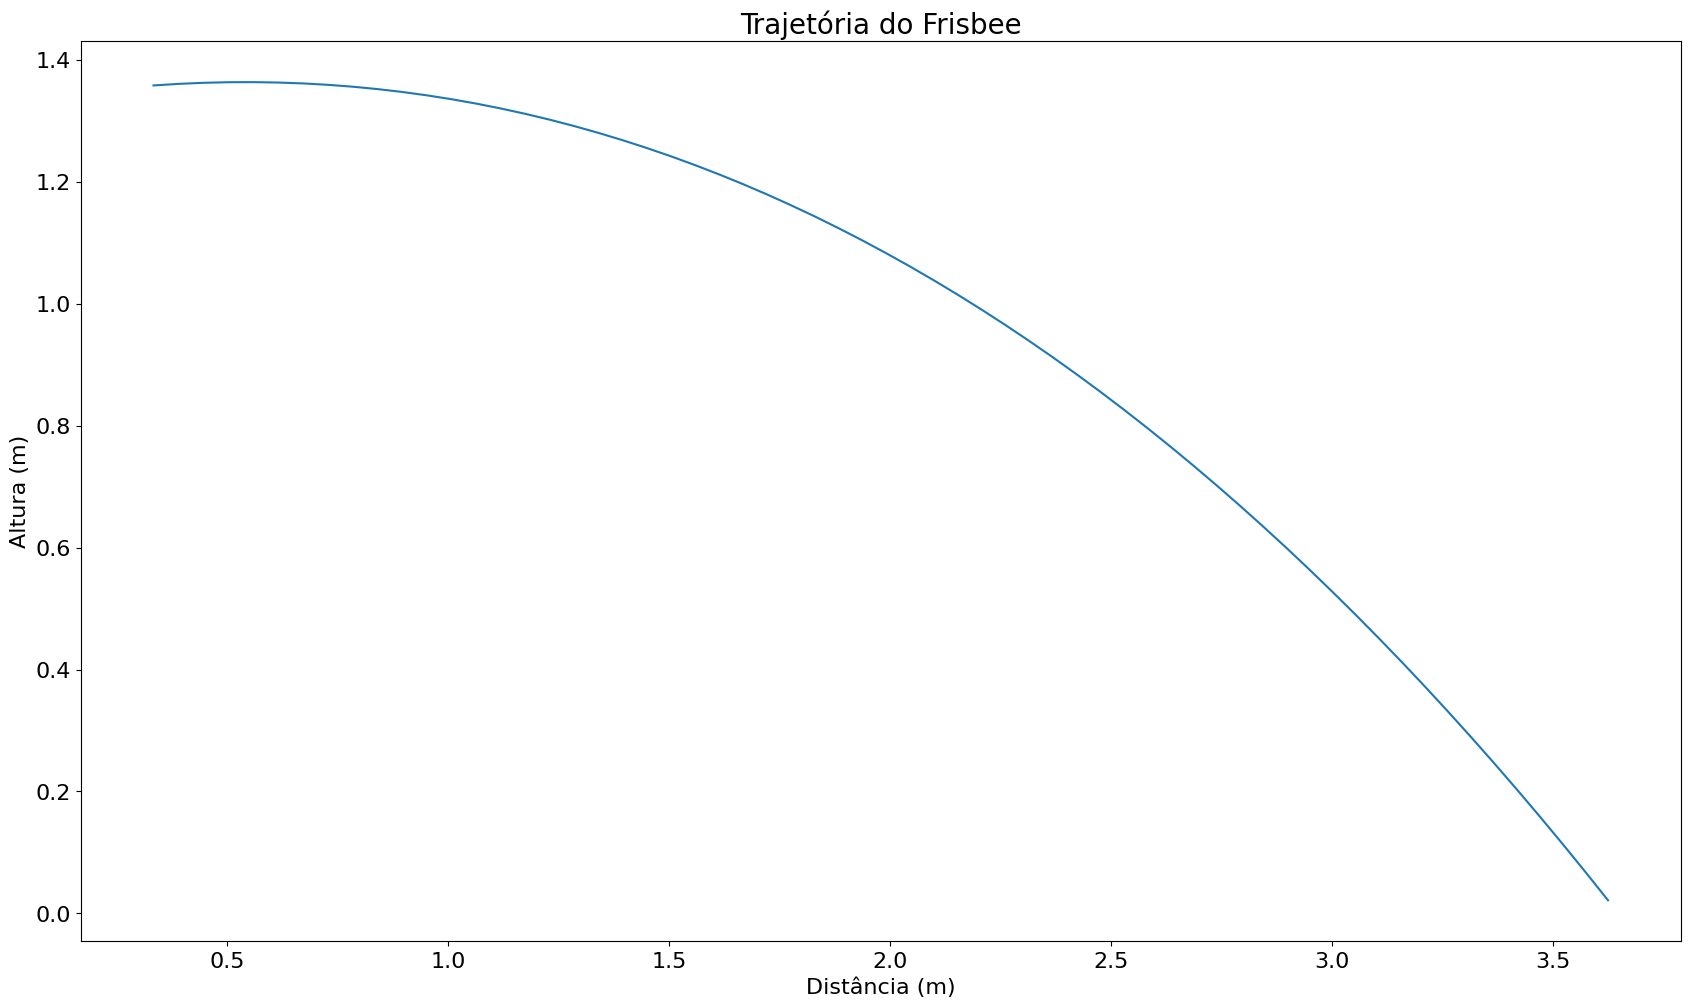

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import pow

# Condições iniciais
x0 = 0.334                # Posição inicial no eixo x (m)
y0 = 1.358              # Posição inicial no eixo y (m)
a = np.radians(3)   # Ângulo de ataque inicial em radianos (conversão de 10 graus)
v0 = 5.673             # velocidade inicial
vx0 = v0 * np.cos(a)  # Velocidade inicial no eixo x (m/s)
vy0 = v0 * np.sin(a)  # Velocidade inicial no eixo y (m/s)

# Propriedades físicas do frisbee e do ambiente
d = 0.213     # Diâmetro do frisbee (m)
m = 0.089    # Massa do frisbee (kg)
rho = 1.23   # Densidade do ar (kg/m³)
g = 9.81     # Aceleração da gravidade (m/s²)
A = np.pi * (d / 2) ** 2  # Área frontal do frisbee (m²)

# Coeficientes aerodinâmicos
CD0 = 0.08   # Coeficiente de arrasto básico (adimensional)
CDa = 2.72   # Dependência do coeficiente de arrasto com o ângulo de ataque (adimensional)
CL0 = 0.15   # Coeficiente de sustentação básico (adimensional)
CLa = 1.4    # Dependência do coeficiente de sustentação com o ângulo de ataque (adimensional)

a0 = np.radians(-4)  # Ângulo de ataque de referência para o arrasto (em radianos)

# Função para calcular o termo relacionado ao coeficiente de arrasto
def KD(a: np.radians):
    """
    Calcula o coeficiente de arrasto (CD) ajustado para o ângulo de ataque atual e retorna
    o termo KD, que combina o coeficiente de arrasto, área, densidade do ar e massa.

    a: Ângulo de ataque em radianos
    Retorno: KD (1/s)
    """
    CD = CD0 + CDa * (a - a0) ** 2  # Coeficiente de arrasto total (adimensional)
    return CD * A * rho / (2 * m)   # KD incorpora as propriedades físicas do frisbee e do ar

# Função para calcular o termo relacionado ao coeficiente de sustentação
def KL(a: np.radians):
    """
    Calcula o coeficiente de sustentação (CL) ajustado para o ângulo de ataque atual e retorna
    o termo KL, que combina o coeficiente de sustentação, área, densidade do ar e massa.

    a: Ângulo de ataque em radianos
    Retorno: KL (1/s)
    """
    CL = CL0 + CLa * a  # Coeficiente de sustentação total (adimensional)
    return CL * A * rho / (2 * m)  # KL incorpora as propriedades físicas do frisbee e do ar

# Termos aerodinâmicos usados no modelo
kl = KL(a)  # Termo relacionado à sustentação ajustado para o ângulo inicial (1/s)
kd = KD(a)  # Termo relacionado ao arrasto ajustado para o ângulo inicial (1/s)

# Constantes de integração derivadas das condições iniciais
C1 = 1 / vx0                              # Constante associada à velocidade inicial no eixo x (s/m)
C2 = x0 - 1 / kd * np.log(np.abs(C1))     # Constante associada à posição inicial no eixo x (m)
C3 = vy0 + kl / kd * vx0                  # Constante associada à velocidade inicial no eixo y (m/s)
C4 = y0 + kl / kd**2 * np.log(np.abs(C1)) # Constante associada à posição inicial no eixo y (m)

# Funções paramétricas para a posição do frisbee ao longo do tempo
x = lambda t: 1 / kd * np.log(np.abs(kd * t + C1)) + C2                               # Posição no eixo x (m)
y = lambda t: -kl / kd**2 * np.log(np.abs(kd * t + C1)) - g / 2 * t**2 + C3 * t + C4  # Posição no eixo y (m)

"""
As funções paramétricas x(t) e y(t) representam a trajetória do frisbee em função do tempo t.
- x(t): Descreve a posição horizontal considerando o termo de arrasto.
- y(t): Descreve a posição vertical considerando os efeitos de sustentação, gravidade e velocidade inicial.
"""

delta_t = 0.01
t = 0.01
x_pos, y_pos = np.array([x0]), np.array([y0])
with open("frisbee_ours.csv", "w+") as csvfile:
    csvfile.write('t,x,y\n')  # Updated header to include vy
    while y(t) >= 0:
        x_v = x(t)
        y_v = y(t)
        x_pos = np.append(x_pos, x_v)
        y_pos = np.append(y_pos, y_v)
        t += delta_t
        csvfile.write(f"{t:.4f},{x_v},{y_v}\n")
fig = plt.figure(figsize=(16, 9))
ax = fig.add_axes([0, 0, 1, 1])  # Position the Axes to fill the figure
ax.plot(x_pos, y_pos)
ax.set_xlabel("Distância (m)", fontsize=16)
ax.set_ylabel("Altura (m)", fontsize=16)
ax.set_title("Trajetória do Frisbee", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
plt.savefig("frisbee_ours.png", bbox_inches='tight')
plt.show()

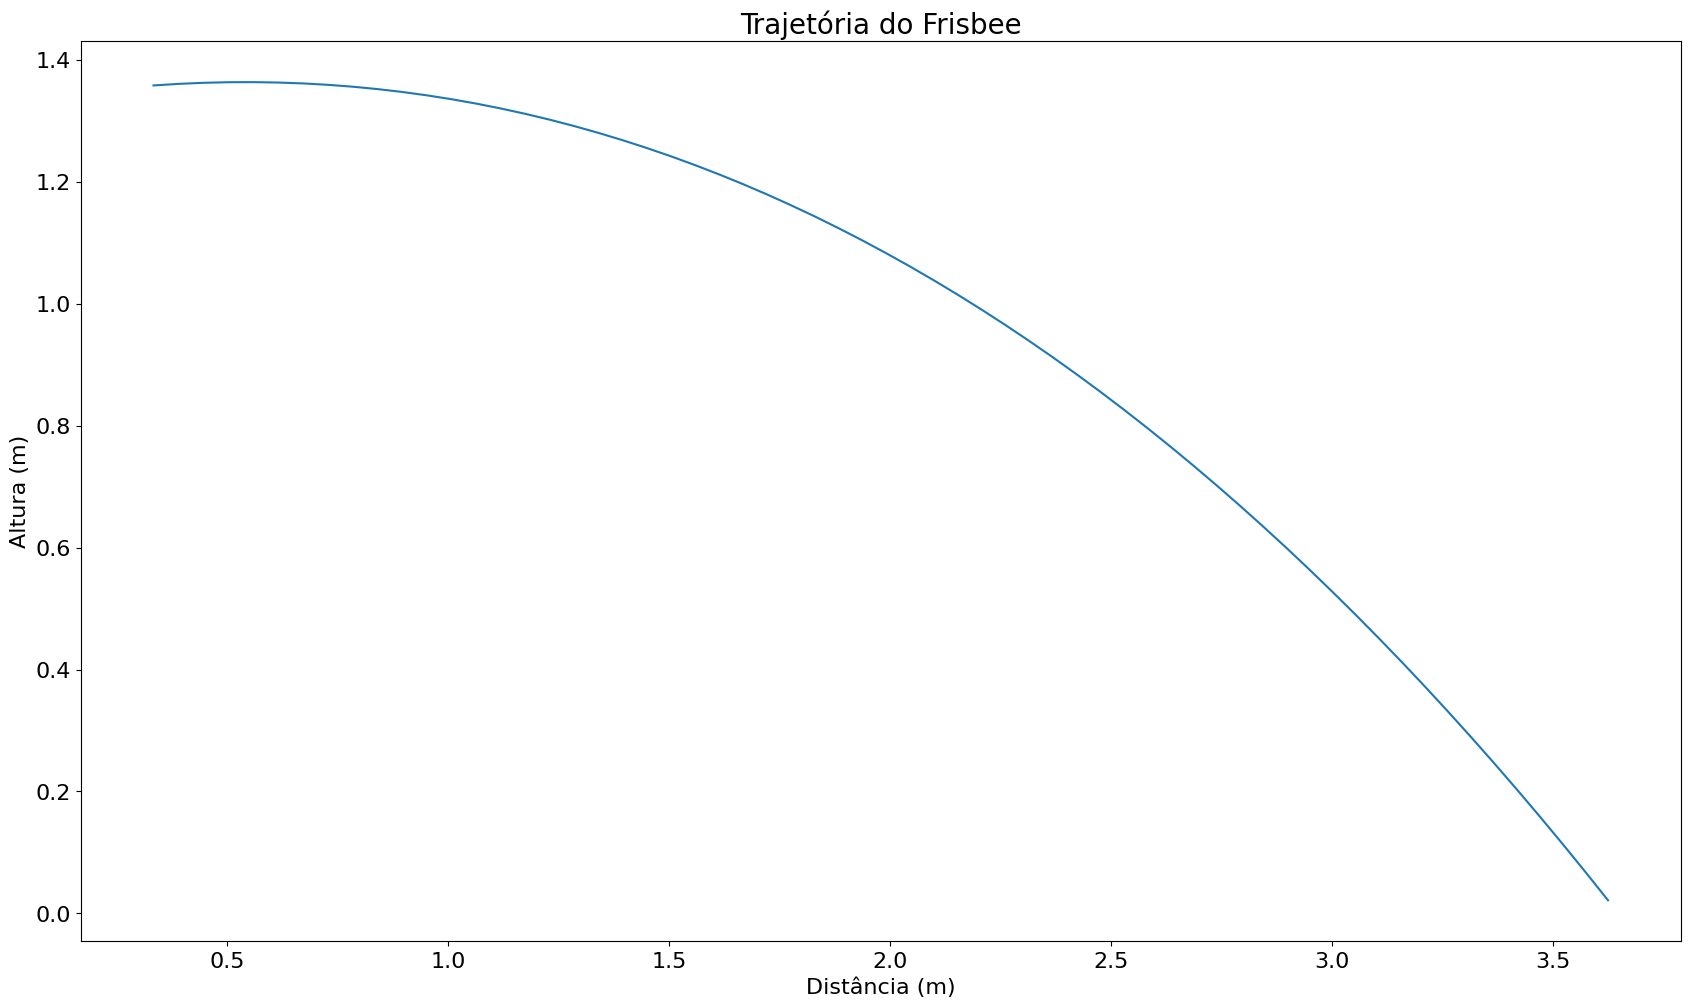

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar os dados do CSV
data = pd.read_csv('tracker-data.csv')  # Substitua pelo nome do seu arquivo

# Extrair as colunas t, x, y
t = data['t']
x_pos_experiment = data['x']
y_pos_experiment = data['y']

# Criar a figura e os eixos
fig = plt.figure(figsize=(16, 9))
ax = fig.add_axes([0, 0, 1, 1])  # Posicionar os eixos para preencher a figura

# Plotar os dados
ax.plot(x_pos, y_pos)

# Personalizar o gráfico
ax.set_xlabel("Distância (m)", fontsize=16)
ax.set_ylabel("Altura (m)", fontsize=16)
ax.set_title("Trajetória do Frisbee", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)

# Salvar o gráfico como imagem
plt.savefig("tracker-experiment.png", bbox_inches='tight')

# Mostrar o gráfico
plt.show()


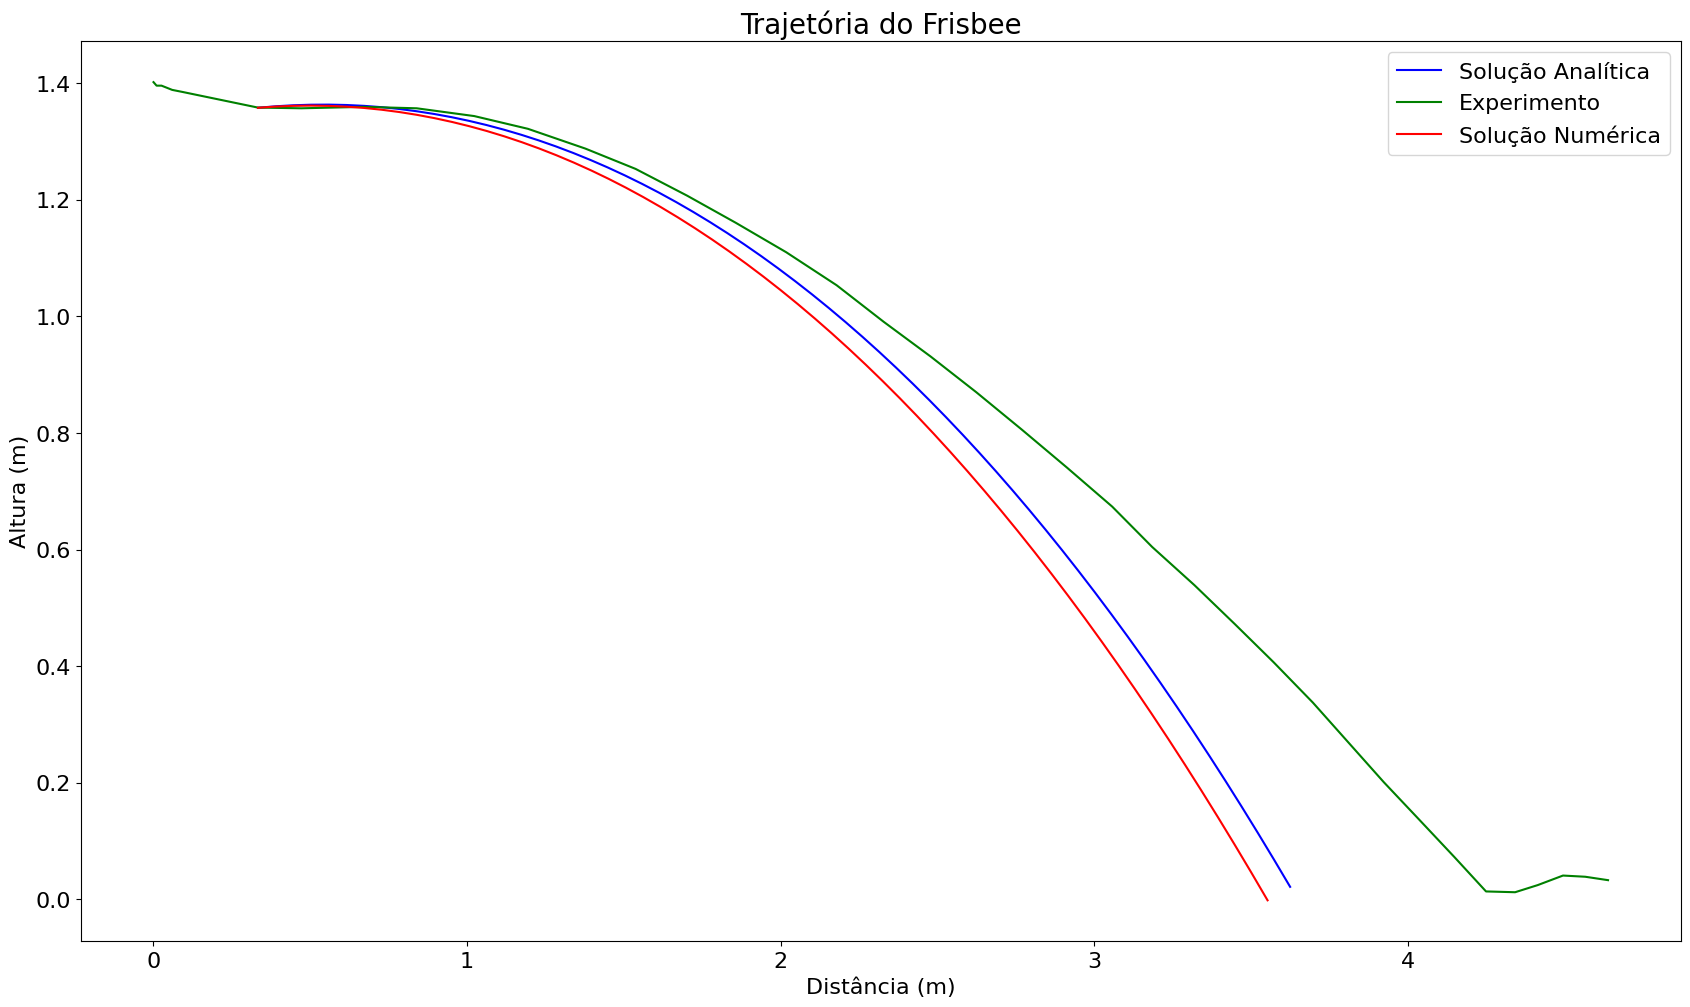

In [3]:
import math

# Constants
g = -9.81     # Acceleration due to gravity (m/s^2)
m = 0.089     # Mass of the frisbee (kg)
RHO = 1.23    # Air density (kg/m^3)
AREA = np.pi * pow(d/2, 2) # Frisbee area (m^2)
CL0 = 0.15     # Lift coefficient at alpha = 0
CLA = 1.4     # Lift coefficient dependent on alpha
CD0 = 0.08    # Drag coefficient at alpha = 0
CDA = 2.72    # Drag coefficient dependent on alpha
ALPHA0 = -4   # Reference angle (degrees)

def simulate(y0, vx0, vy0, alpha, deltaT):
    # Convert angles from degrees to radians
    alpha_rad = math.radians(alpha)
    alpha0_rad = math.radians(ALPHA0)
    x_pos_list, y_pos_list = [x0], [y0]
    t = 0.01


    # Calculate lift and drag coefficients
    cl = CL0 + CLA * alpha_rad
    cd = CD0 + CDA * (alpha_rad - alpha0_rad) ** 2

    # Initial positions and velocities
    x = 0.334
    y = y0
    vx = vx0
    vy = vy0
    i = 0

    # Open file to write output
    with open("frisbee_theirs.csv", "w+") as csvfile:
        csvfile.write('t,x,y\n')  # Updated header to include vy

        # Simulation loop
        while y > 0:
            # Calculate changes in velocities
            deltavy = ((RHO * vx ** 2 * AREA * cl) / (2 * m) + g) * deltaT
            deltavx = (- RHO * vx ** 2 * AREA * cd / (2 * m)) * deltaT 

            # Update velocities
            vx += deltavx
            vy += deltavy

            # Update positions
            x += vx * deltaT
            y += vy * deltaT
            x_pos_list.append(x)
            y_pos_list.append(y)

            # Write data every tenth iteration
            t += deltaT
            csvfile.write(f"{t:.4f},{x},{y}\n")  # Include vy in output
    return x_pos_list, y_pos_list

# Example usage
if __name__ == "__main__":
    x_pos_, y_pos_ = simulate(y0=y0, vx0=v0 * np.cos(a), vy0=v0 * np.sin(a), alpha=a, deltaT=0.01)
    fig = plt.figure(figsize=(16, 9))
    ax = fig.add_axes([0, 0, 1, 1])  # Position the Axes to fill the figure
    ax.plot(x_pos, y_pos, label="Solução Analítica", color="blue")
    ax.plot(x_pos_experiment, y_pos_experiment, label="Experimento", color="green")
    ax.plot(x_pos_, y_pos_, label="Solução Numérica", color="red")
    ax.set_xlabel("Distância (m)", fontsize=16)
    ax.set_ylabel("Altura (m)", fontsize=16)
    ax.set_title("Trajetória do Frisbee", fontsize=20)
    ax.legend(fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=16)
    plt.savefig("frisbee_comparison_experiment_all_models.png", bbox_inches='tight')
    plt.show()

# Simulações

### Teste 1

```python
# Condições iniciais
x0 = 0                 # Posição inicial no eixo x (m)
y0 = 1                # Posição inicial no eixo y (m)
a = np.radians(5)      # Ângulo de ataque inicial em radianos (conversão de 10 graus)
v0 = 18               # velocidade inicial
vx0 = v0 * np.cos(a)   # Velocidade inicial no eixo x (m/s)
vy0 = v0 * np.sin(a)   # Velocidade inicial no eixo y (m/s)
```

### Teste 2

```python
# Condições iniciais
x0 = 0                # Posição inicial no eixo x (m)
y0 = 1                # Posição inicial no eixo y (m)
a = np.radians(7.5)   # Ângulo de ataque inicial em radianos (conversão de 10 graus)
v0 = 18               # velocidade inicial
vx0 = v0 * np.cos(a)  # Velocidade inicial no eixo x (m/s)
vy0 = v0 * np.sin(a)  # Velocidade inicial no eixo y (m/s)
```

### Teste 3

```python
# Condições iniciais
x0 = 0                # Posição inicial no eixo x (m)
y0 = 1                # Posição inicial no eixo y (m)
a = np.radians(0)   # Ângulo de ataque inicial em radianos (conversão de 10 graus)
v0 = 14               # velocidade inicial
vx0 = v0 * np.cos(a)  # Velocidade inicial no eixo x (m/s)
vy0 = v0 * np.sin(a)  # Velocidade inicial no eixo y (m/s)
```

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=983d1a9b-1f65-4ae3-870e-24892c95f5f8' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>